# Install Library

In [1]:
# Library Scrapping 
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Get HTML Content 

In [2]:
# First of all we need to check the capability of the website ("https://www.worldometers.info/water") to be scrapped
Link  = "https://www.worldometers.info/water"
page = requests.get(Link)

In [3]:
# Check status response
if page.status_code == 200:
    print("Page is accessible")

Page is accessible


In [4]:
# Check Content
print(page.content)

b'<!DOCTYPE html><html lang="en"> <head><meta charset="UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=edge"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Water Use Statistics - Worldometer</title><script async src="https://www.googletagmanager.com/gtag/js?id=G-ZDP3BFSX60"></script> <script>\n    window.dataLayer = window.dataLayer || [];\n    function gtag() {\n        dataLayer.push(arguments);\n    }\n    gtag("js", new Date());\n    gtag("config", "G-ZDP3BFSX60");\n</script><script src="https://pagead2.googlesyndication.com/pagead/js/adsbygoogle.js?client=ca-pub-3701697624350410" crossorigin="anonymous"></script> <script async src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script> <link rel="preconnect" href="https://a.pub.network/" crossorigin><link rel="preconnect" href="https://b.pub.network/" crossorigin><link rel="preconnect" href="https://c.pub.network/" crossorigin><link rel="preconnect" href="https://d.pub.network/" crossorig

In [5]:
# Pretty print the content
soup = BeautifulSoup(page.content, 'html.parser')
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <title>
   Water Use Statistics - Worldometer
  </title>
  <script async="" src="https://www.googletagmanager.com/gtag/js?id=G-ZDP3BFSX60">
  </script>
  <script>
   window.dataLayer = window.dataLayer || [];
    function gtag() {
        dataLayer.push(arguments);
    }
    gtag("js", new Date());
    gtag("config", "G-ZDP3BFSX60");
  </script>
  <script crossorigin="anonymous" src="https://pagead2.googlesyndication.com/pagead/js/adsbygoogle.js?client=ca-pub-3701697624350410">
  </script>
  <script async="" src="https://securepubads.g.doubleclick.net/tag/js/gpt.js">
  </script>
  <link crossorigin="" href="https://a.pub.network/" rel="preconnect"/>
  <link crossorigin="" href="https://b.pub.network/" rel="preconnect"/>
  <link crossorigin="" href="https://c.pub.network/" rel="preconnect"/>


# Inspect Element form Web and extract the content

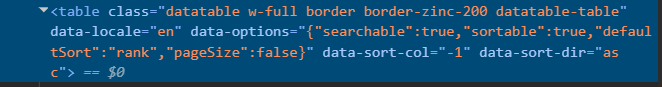

In [11]:
# Step 2: Find the table
table = soup.find("table", class_="datatable w-full border border-zinc-200")

In [12]:
print(table)

<table class="datatable w-full border border-zinc-200" data-locale="en" data-options='{"searchable":true,"sortable":true,"defaultSort":"rank","pageSize":false}' data-sort-col="-1" data-sort-dir="asc"> <thead> <tr> <th class="px-2 border-e border-zinc-200 align-middle text-center font-semibold border-b-3 py-1" data-sortable="true"> <span>Country</span> <svg aria-hidden="true" class="size-4 shrink-0" data-sorting-icon="true" fill="none" viewbox="0 0 24 24" xmlns="http://www.w3.org/2000/svg"> <path d="m8 15 4 4 4-4m0-6-4-4-4 4" stroke="currentColor" stroke-linecap="round" stroke-linejoin="round" stroke-width="2"></path> </svg> </th><th class="px-2 border-e border-zinc-200 align-middle text-center font-semibold border-b-3 py-1" data-sortable="true"> <span>Yearly<br>Water Used<br/><small>(m³, thousand of litres)</small></br></span> <svg aria-hidden="true" class="size-4 shrink-0" data-sorting-icon="true" fill="none" viewbox="0 0 24 24" xmlns="http://www.w3.org/2000/svg"> <path d="m8 15 4 4 4

In [15]:
# Pretty print the table content
print(table.prettify())

<table class="datatable w-full border border-zinc-200" data-locale="en" data-options='{"searchable":true,"sortable":true,"defaultSort":"rank","pageSize":false}' data-sort-col="-1" data-sort-dir="asc">
 <thead>
  <tr>
   <th class="px-2 border-e border-zinc-200 align-middle text-center font-semibold border-b-3 py-1" data-sortable="true">
    <span>
     Country
    </span>
    <svg aria-hidden="true" class="size-4 shrink-0" data-sorting-icon="true" fill="none" viewbox="0 0 24 24" xmlns="http://www.w3.org/2000/svg">
     <path d="m8 15 4 4 4-4m0-6-4-4-4 4" stroke="currentColor" stroke-linecap="round" stroke-linejoin="round" stroke-width="2">
     </path>
    </svg>
   </th>
   <th class="px-2 border-e border-zinc-200 align-middle text-center font-semibold border-b-3 py-1" data-sortable="true">
    <span>
     Yearly
     <br>
      Water Used
      <br/>
      <small>
       (m³, thousand of litres)
      </small>
     </br>
    </span>
    <svg aria-hidden="true" class="size-4 shrink-0"

In [ ]:
# Extract the headers
headers = []
for th in table.find_all("th"):
    headers.append(th.text.strip())
print(headers)

['Country', 'YearlyWater Used(m³, thousand of litres)', 'Daily Water UsedPer Capita (litres)', 'Population']


In [14]:
# Extract the rows
rows = []
for tr in table.find_all("tr")[1:]:  # Skip the header row
    cols = tr.find_all("td")
    cols = [ele.text.strip() for ele in cols]
    rows.append([ele for ele in cols if ele])  # Get rid of empty values
print(rows)

[['Afghanistan', '20,280,000,000  Year: 2000', '2,760', '20,130,327  Year: 2000'], ['Albania', '1,311,000,000  Year: 2006', '1,177', '3,050,809  Year: 2006'], ['Algeria', '9,978,000,000  Year: 2016', '669', '40,850,721  Year: 2016'], ['Angola', '705,800,000  Year: 2005', '100', '19,291,161  Year: 2005'], ['Antigua and Barbuda', '11,500,000  Year: 2012', '361', '87,260  Year: 2012'], ['Argentina', '37,780,000,000  Year: 2011', '2,480', '41,730,660  Year: 2011'], ['Armenia', '2,847,000,000  Year: 2017', '2,676', '2,914,963  Year: 2017'], ['Australia', '16,130,000,000  Year: 2016', '1,816', '24,329,963  Year: 2016'], ['Austria', '3,492,000,000  Year: 2010', '1,144', '8,365,092  Year: 2010'], ['Azerbaijan', '12,780,000,000  Year: 2017', '3,512', '9,968,510  Year: 2017'], ['Bahrain', '434,400,000  Year: 2016', '832', '1,429,604  Year: 2016'], ['Bangladesh', '35,870,000,000  Year: 2008', '657', '149,474,264  Year: 2008'], ['Barbados', '81,000,000  Year: 2005', '826', '268,706  Year: 2005'], 

In [16]:
# Create a DataFrame
df = pd.DataFrame(rows, columns=headers)
df.head()

,Country,"YearlyWater Used(m³, thousand of litres)",Daily Water UsedPer Capita (litres),Population
0,Afghanistan,"20,280,000,000 Year: 2000","2,760","20,130,327 Year: 2000"
1,Albania,"1,311,000,000 Year: 2006","1,177","3,050,809 Year: 2006"
2,Algeria,"9,978,000,000 Year: 2016",669,"40,850,721 Year: 2016"
3,Angola,"705,800,000 Year: 2005",100,"19,291,161 Year: 2005"
4,Antigua and Barbuda,"11,500,000 Year: 2012",361,"87,260 Year: 2012"


# Cleaning dataframe

In [18]:
# Clean YearlyWater Used(m³, thousand of litres)
# Delete string ("Year: xxxx") (anything after Year:)
df['YearlyWater Used(m³, thousand of litres)'] = df['YearlyWater Used(m³, thousand of litres)'].str.split(' ').str[0]
df.head()

,Country,"YearlyWater Used(m³, thousand of litres)",Daily Water UsedPer Capita (litres),Population
0,Afghanistan,"20,280,000,000","2,760","20,130,327 Year: 2000"
1,Albania,"1,311,000,000","1,177","3,050,809 Year: 2006"
2,Algeria,"9,978,000,000",669,"40,850,721 Year: 2016"
3,Angola,"705,800,000",100,"19,291,161 Year: 2005"
4,Antigua and Barbuda,"11,500,000",361,"87,260 Year: 2012"


In [19]:
# Clean Population
# Delete string ("Year: xxxx") (anything after Year:)
df['Population'] = df['Population'].str.split(' ').str[0]
df.head()

,Country,"YearlyWater Used(m³, thousand of litres)",Daily Water UsedPer Capita (litres),Population
0,Afghanistan,"20,280,000,000","2,760","20,130,327"
1,Albania,"1,311,000,000","1,177","3,050,809"
2,Algeria,"9,978,000,000",669,"40,850,721"
3,Angola,"705,800,000",100,"19,291,161"
4,Antigua and Barbuda,"11,500,000",361,"87,260"


In [22]:
# Remove commas from the columns
df['YearlyWater Used(m³, thousand of litres)'] = df['YearlyWater Used(m³, thousand of litres)'].str.replace(',', '')
df['Population'] = df['Population'].str.replace(',', '')
df['Daily Water UsedPer Capita (litres)'] = df['Daily Water UsedPer Capita (litres)'].str.replace(',', '')
df.head()

,Country,"YearlyWater Used(m³, thousand of litres)",Daily Water UsedPer Capita (litres),Population
0,Afghanistan,20280000000,2760,20130327
1,Albania,1311000000,1177,3050809
2,Algeria,9978000000,669,40850721
3,Angola,705800000,100,19291161
4,Antigua and Barbuda,11500000,361,87260


In [23]:
# Convert columns to numeric
df['YearlyWater Used(m³, thousand of litres)'] = pd.to_numeric(df['YearlyWater Used(m³, thousand of litres)'], errors='coerce')
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
df['Daily Water UsedPer Capita (litres)'] = pd.to_numeric(df['Daily Water UsedPer Capita (litres)'], errors='coerce')
# Check the data types
print(df.dtypes)

Country                                     object
YearlyWater Used(m³, thousand of litres)     int64
Daily Water UsedPer Capita (litres)          int64
Population                                   int64
dtype: object


In [24]:
# Check the dataframe
df

,Country,"YearlyWater Used(m³, thousand of litres)",Daily Water UsedPer Capita (litres),Population
0,Afghanistan,20280000000,2760,20130327
1,Albania,1311000000,1177,3050809
2,Algeria,9978000000,669,40850721
3,Angola,705800000,100,19291161
4,Antigua and Barbuda,11500000,361,87260
...,...,...,...,...
176,Venezuela,22630000000,2242,27649363
177,Vietnam,82030000000,2772,81088313
178,Yemen,3565000000,429,22790085
179,Zambia,1572000000,404,10647949


In [25]:
# Save to CSV
df.to_csv('water_usage.csv', index=False)